In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os            # for creating directories to save generated images
import time          # to measure how long each epoch takes

import numpy as np   # numerical operations
import pandas as pd  # data handling (used for class names table)

import matplotlib.pyplot as plt      # plotting images and loss curves
import matplotlib.gridspec as gridspec

import tensorflow as tf              # main deep learning framework
from tensorflow import keras         # high-level Keras API
from tensorflow.keras import layers  # neural network layers


In [5]:
!nvidia-smi

Mon May 25 09:08:33 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   47C    P8             13W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [4]:
print("TensorFlow version:", tf.__version__)
print("Keras version:     ", keras.__version__)

TensorFlow version: 2.20.0
Keras version:      3.13.2


In [7]:
TEST_PATH  = "/content/drive/MyDrive/final project/data/fashion-mnist_test.csv"
TRAIN_PATH   = "/content/drive/MyDrive/final project/data/fashion-mnist_train.csv"

In [9]:
# Load the variables safely

train_df = pd.read_csv(TRAIN_PATH)
test_df = pd.read_csv(TEST_PATH)



print("Train shape:", train_df.shape)
print("Test shape :", test_df.shape)


train_df.head()

Train shape: (60000, 785)
Test shape : (10000, 785)


,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,6,0,0,0,0,0,0,0,5,0,...,0,0,0,30,43,0,0,0,0,0
3,0,0,0,0,1,2,0,0,0,0,...,3,0,0,0,0,1,0,0,0,0
4,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [10]:
# Fashion MNIST has 10 categories. Each label (0–9) corresponds to a clothing item.
CLASS_NAMES = [
    "T-shirt/top",  # 0
    "Trouser",      # 1
    "Pullover",     # 2
    "Dress",        # 3
    "Coat",         # 4
    "Sandal",       # 5
    "Shirt",        # 6
    "Sneaker",      # 7
    "Bag",          # 8
    "Ankle boot"    # 9
]

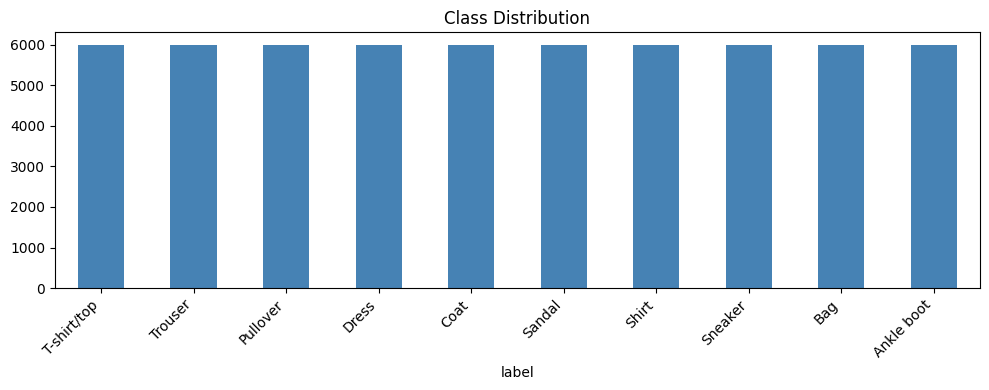

In [11]:
plt.figure(figsize=(10, 4))
train_df['label'].value_counts().sort_index().plot(kind='bar', color='steelblue')
plt.xticks(range(10), CLASS_NAMES, rotation=45, ha='right')
plt.title("Class Distribution")
plt.tight_layout()
plt.show()

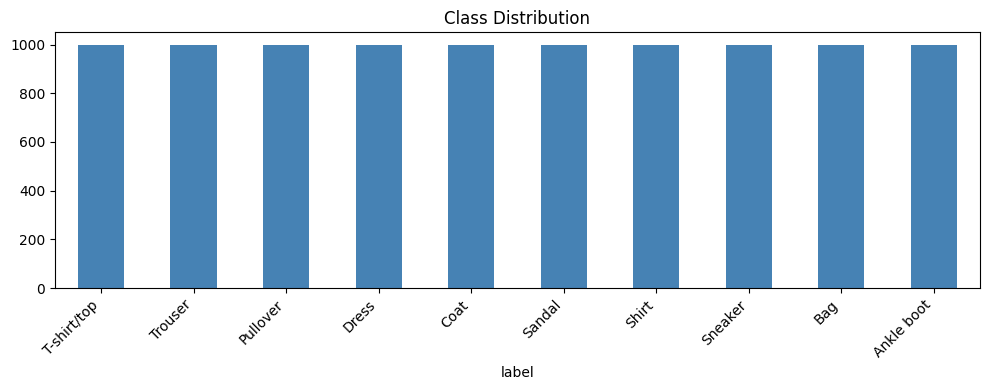

In [12]:
plt.figure(figsize=(10, 4))
test_df['label'].value_counts().sort_index().plot(kind='bar', color='steelblue')
plt.xticks(range(10), CLASS_NAMES, rotation=45, ha='right')
plt.title("Class Distribution")
plt.tight_layout()
plt.show()

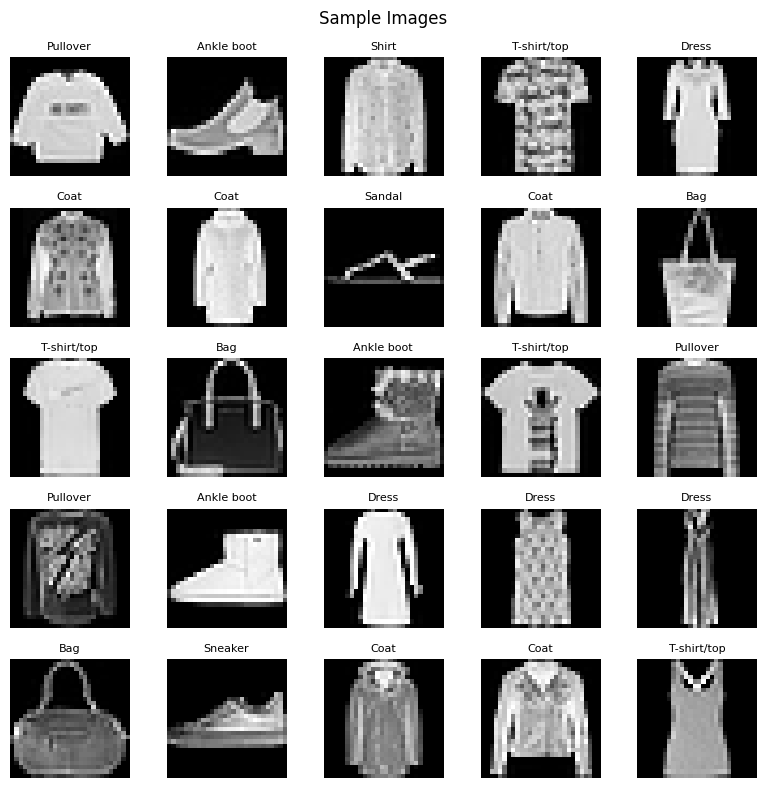

In [13]:
X_sample = train_df.iloc[:25, 1:].values.reshape(-1, 28, 28)
fig, axes = plt.subplots(5, 5, figsize=(8, 8))
for i, ax in enumerate(axes.flat):
    ax.imshow(X_sample[i], cmap='gray')
    ax.set_title(CLASS_NAMES[train_df.iloc[i]['label']], fontsize=8)
    ax.axis('off')
plt.suptitle("Sample Images")
plt.tight_layout()
plt.show()